# Online Shoppers Intention Analysis

数据集信息：**Online Shoppers Purchasing Intention Dataset**，来源于 UCI Machine Learning Repository。约 12,330 条用户浏览会话记录，18 个特征（数值型 + 类别型），目标变量 `Revenue`（是否产生购买，True/False）。

In [5]:
# 统一导入所有依赖
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    silhouette_score,
    f1_score,
)

import warnings
warnings.filterwarnings("ignore")

## Part 1: 数据加载与探索性分析

In [6]:
# 基础显示设置
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False

# 启用常见中文字体
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS", "DejaVu Sans"]

# 统一实验配置，避免魔数散落在各个代码单元
CONFIG = {
    "RANDOM_SEED": 42,
    "TEST_SIZE": 0.2,
    "CV_FOLDS": 5,
    "SCORING_MAIN": "f1"
}

### a. 数据加载与基础检查
读取数据后查看数据规模、样例、字段类型、统计摘要与缺失值情况。

In [7]:
data_path = "data/online_shoppers_intention.csv"
df = pd.read_csv(data_path)

print(f"数据形状: {df.shape}")
display(df.head())

print("\nDataFrame.info():")
df.info()

print("\n数值统计摘要 (describe):")
display(df.describe())

print("\n包含类别变量在内的统计摘要 (describe include='all'):")
display(df.describe(include="all"))

数据形状: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False



DataFrame.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  Tra

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000



包含类别变量在内的统计摘要 (describe include='all'):


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330.000000,12330.000000,12330.000000,12330.000000,12330,12330,12330
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,NaN,NaN,NaN,3,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,May,NaN,NaN,NaN,NaN,Returning_Visitor,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3364,NaN,NaN,NaN,NaN,10551,9462,10422
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,NaN,2.124006,2.357097,3.147364,4.069586,NaN,NaN,NaN
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,NaN,0.911325,1.717277,2.401591,4.025169,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,NaN,2.000000,2.000000,1.000000,2.000000,NaN,NaN,NaN
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,NaN,2.000000,2.000000,3.000000,2.000000,NaN,NaN,NaN
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,NaN,3.000000,2.000000,4.000000,4.000000,NaN,NaN,NaN


In [8]:
# 缺失值统计（数量 + 占比）
missing_count = df.isnull().sum()
missing_ratio = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_ratio_percent": missing_ratio
}).sort_values("missing_ratio_percent", ascending=False)

display(missing_summary)

if missing_summary["missing_count"].sum() == 0:
    print("未发现缺失值。")
else:
    print("存在缺失值，请在后续预处理中处理。")

,missing_count,missing_ratio_percent
Administrative,0,0.0
Administrative_Duration,0,0.0
Informational,0,0.0
Informational_Duration,0,0.0
ProductRelated,0,0.0
ProductRelated_Duration,0,0.0
BounceRates,0,0.0
ExitRates,0,0.0
PageValues,0,0.0
SpecialDay,0,0.0


未发现缺失值。


### b. 目标变量分布分析
统计 `Revenue` 的类别数量与占比

Revenue 类别计数:


,count
Revenue,
False,10422
True,1908


Revenue 类别占比(%):


,ratio_percent
Revenue,
False,84.53
True,15.47


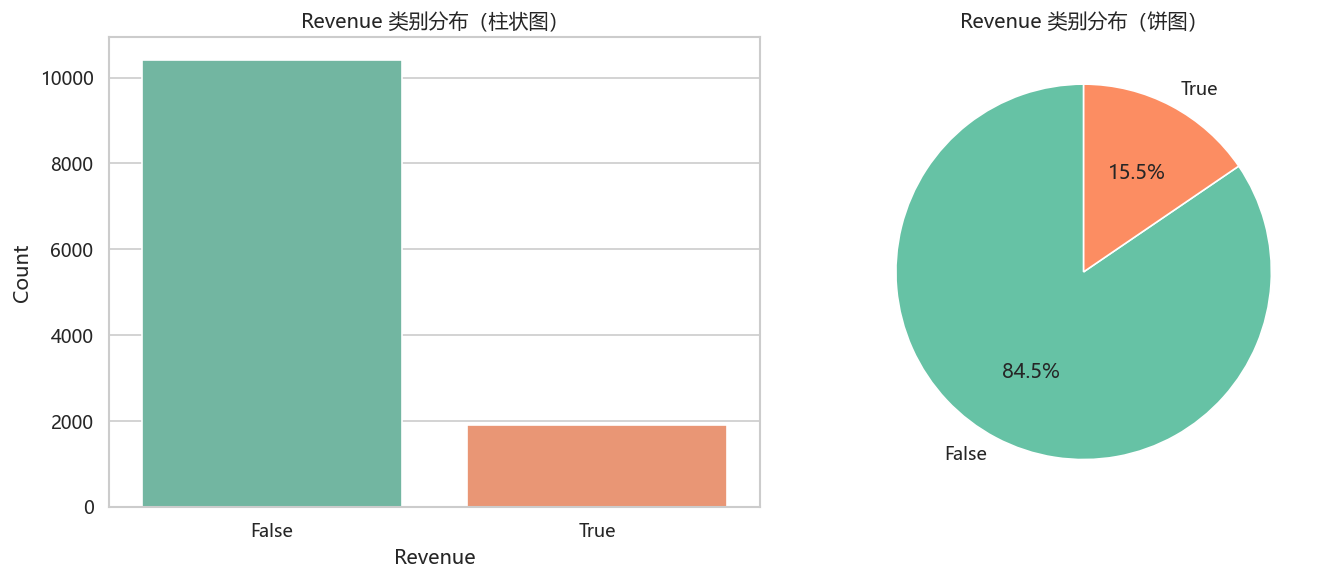

In [9]:
if "Revenue" not in df.columns:
    raise KeyError("未找到目标变量列 'Revenue'。")

revenue_counts = df["Revenue"].value_counts(dropna=False)
revenue_ratio = df["Revenue"].value_counts(normalize=True, dropna=False).mul(100).round(2)

print("Revenue 类别计数:")
display(revenue_counts.to_frame(name="count"))

print("Revenue 类别占比(%):")
display(revenue_ratio.to_frame(name="ratio_percent"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x="Revenue", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Revenue 类别分布（柱状图）")
axes[0].set_xlabel("Revenue")
axes[0].set_ylabel("Count")

axes[1].pie(
    revenue_counts.values,
    labels=revenue_counts.index.astype(str),
    autopct="%.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", n_colors=len(revenue_counts))
)
axes[1].set_title("Revenue 类别分布（饼图）")

plt.tight_layout()
plt.show()

### c. 数值特征分布可视化
绘制数值特征的直方图与箱线图，观察分布形态与异常值

数值特征数量: 14
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']


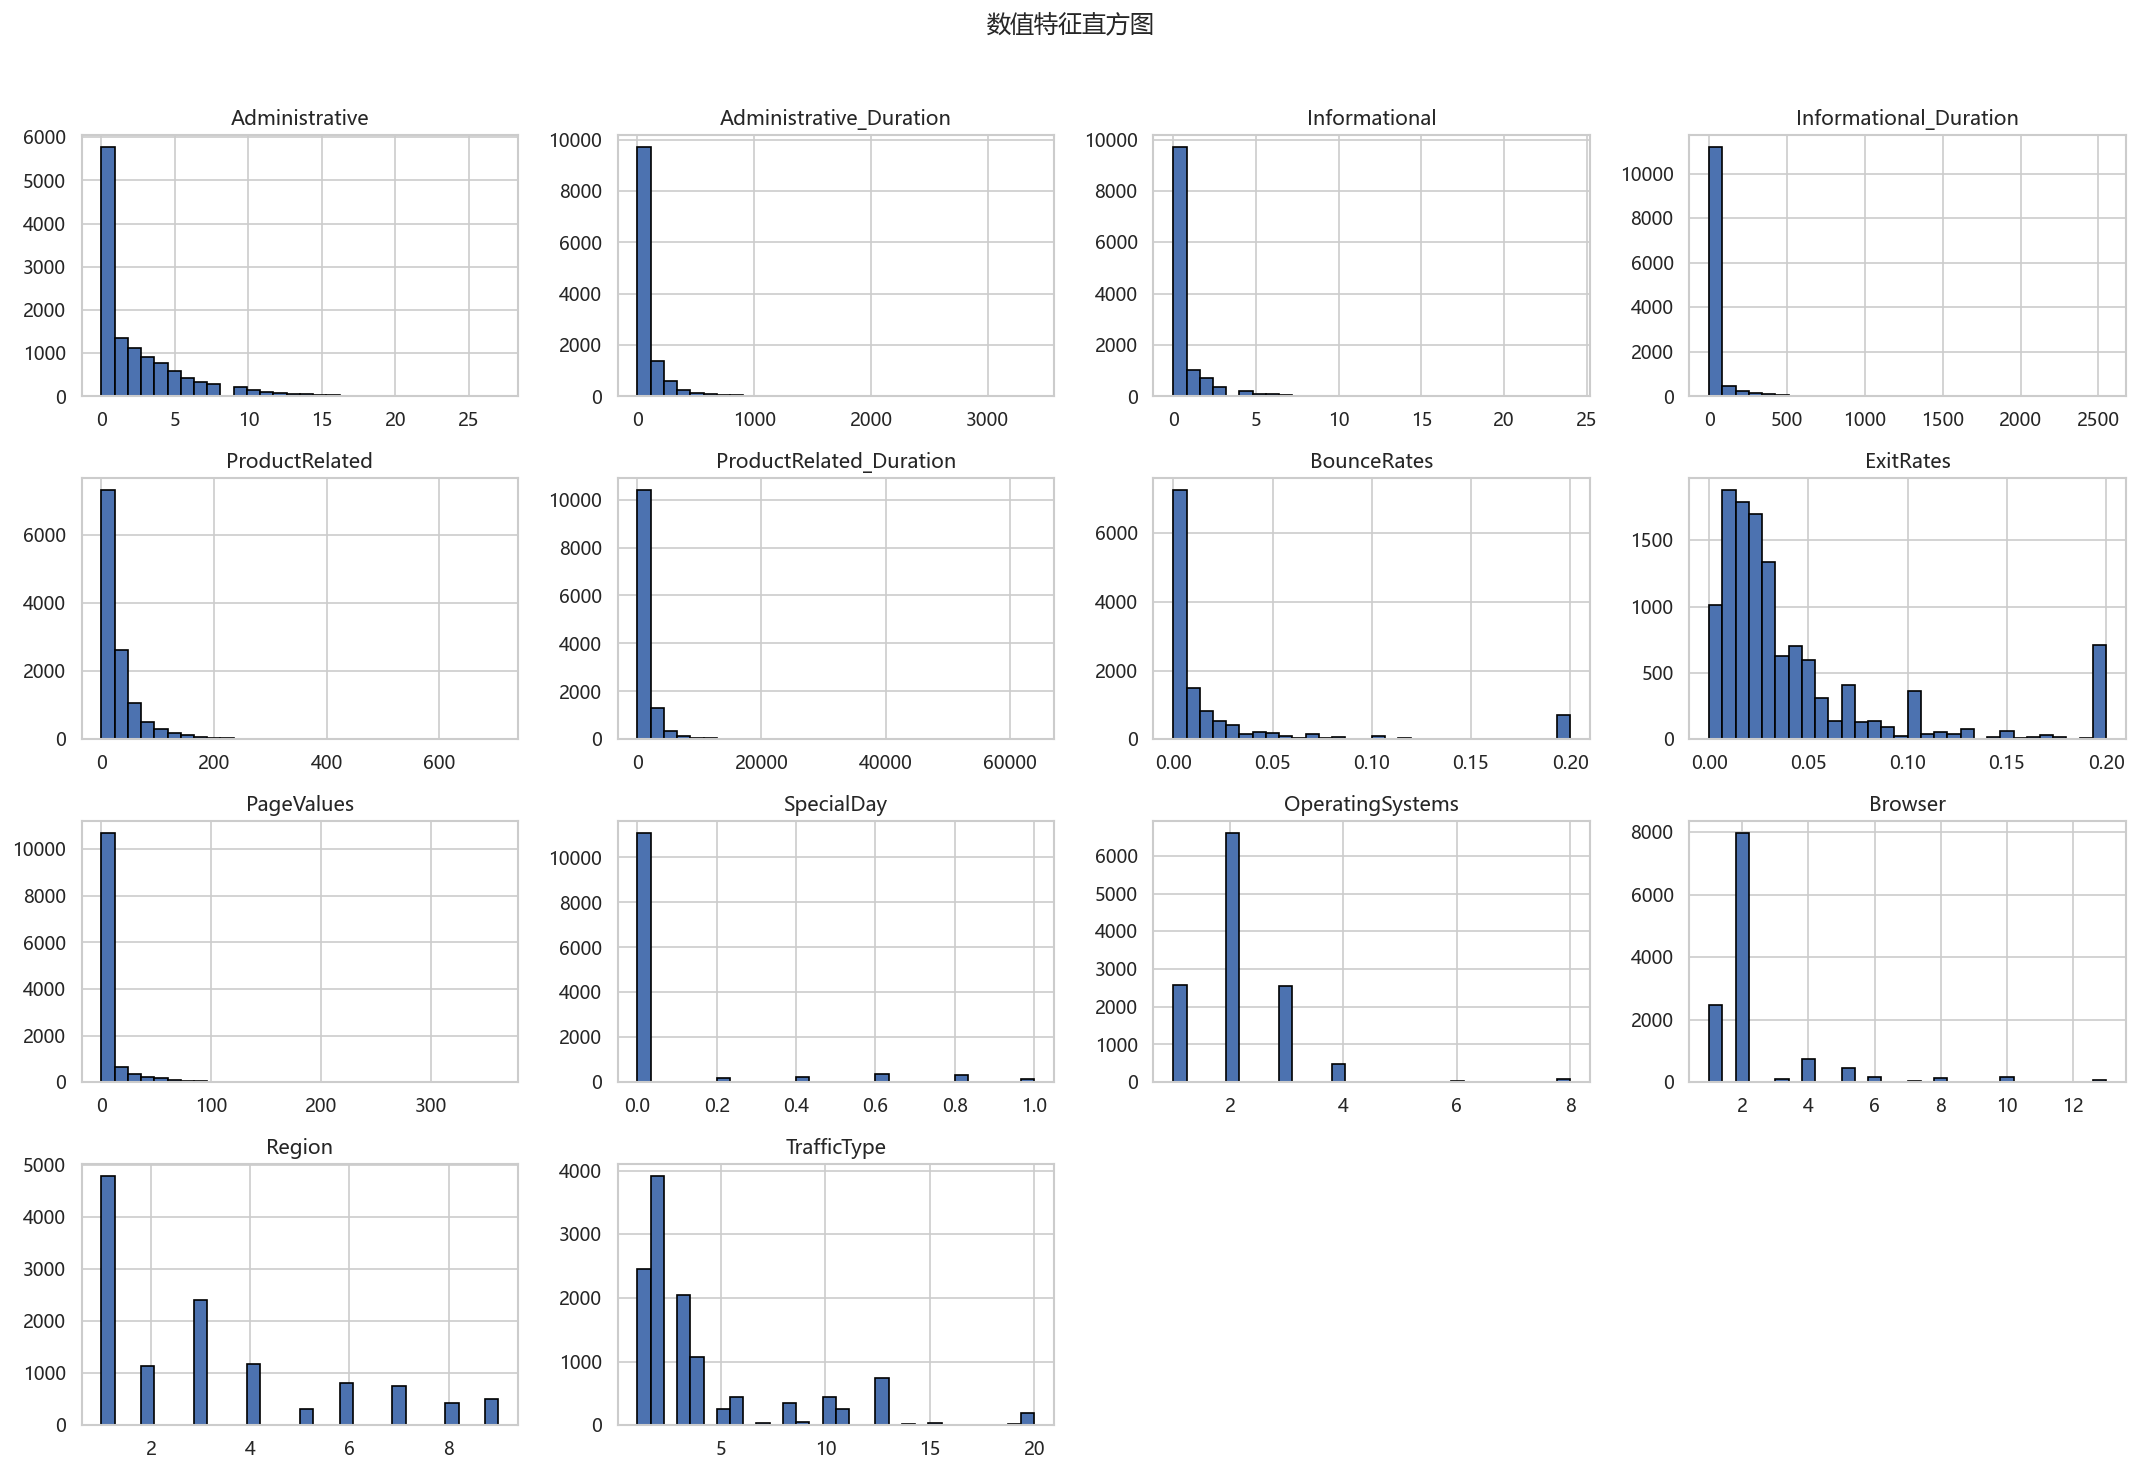

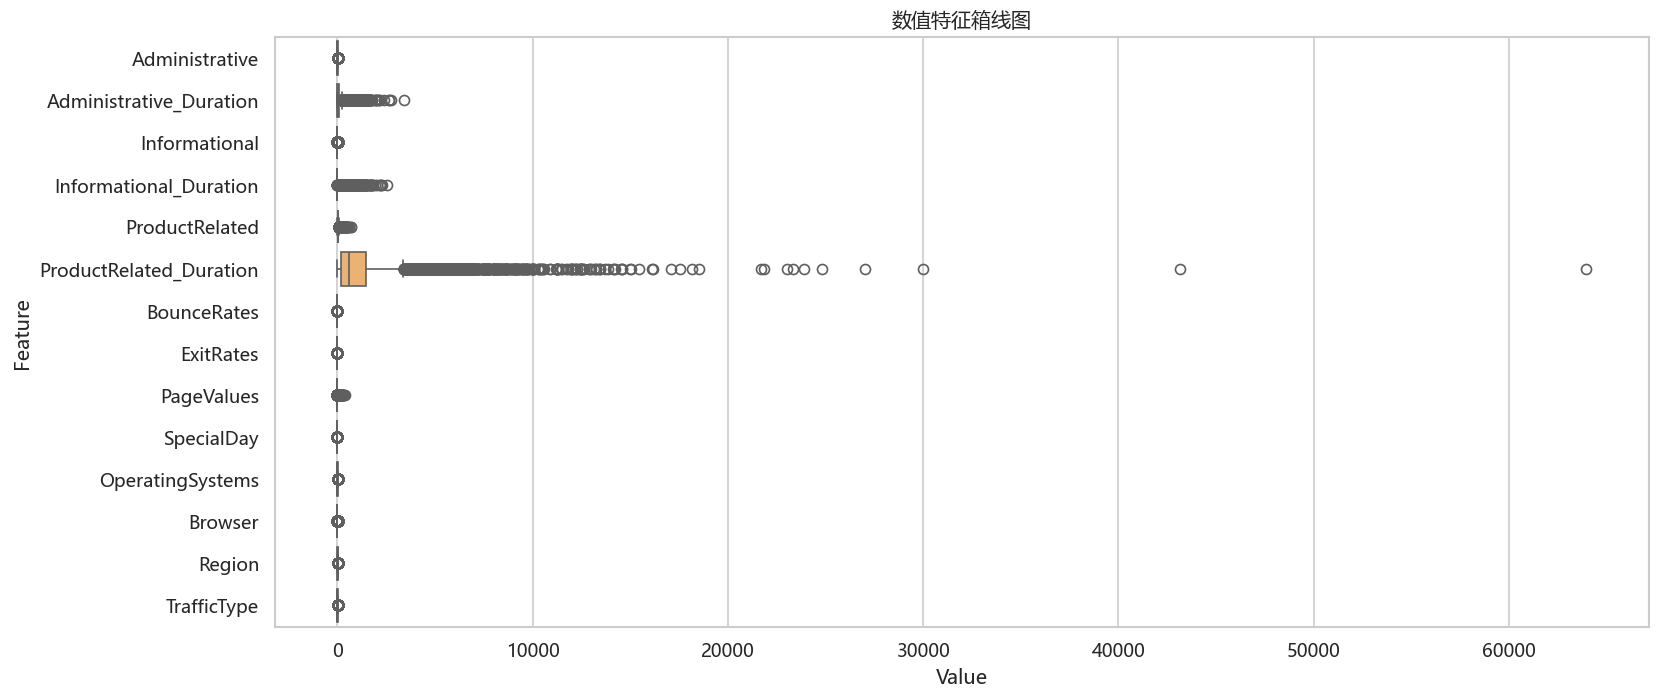

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"数值特征数量: {len(num_cols)}")
print(num_cols)

# 直方图
_ = df[num_cols].hist(bins=30, figsize=(18, 12), edgecolor="black")
plt.suptitle("数值特征直方图", y=1.02)
plt.tight_layout()
plt.show()

# 箱线图
plt.figure(figsize=(14, max(6, len(num_cols) * 0.35)))
sns.boxplot(data=df[num_cols], orient="h", palette="Set3")
plt.title("数值特征箱线图")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### d. 类别特征频率统计
统计 `Month`、`VisitorType`、`Weekend` 的频数与占比


=== Month 频数统计 ===


,count,ratio_percent
Month,,
May,3364,27.28
Nov,2998,24.31
Mar,1907,15.47
Dec,1727,14.01
Oct,549,4.45
Sep,448,3.63
Aug,433,3.51
Jul,432,3.50
June,288,2.34



=== VisitorType 频数统计 ===


,count,ratio_percent
VisitorType,,
Returning_Visitor,10551,85.57
New_Visitor,1694,13.74
Other,85,0.69



=== Weekend 频数统计 ===


,count,ratio_percent
Weekend,,
False,9462,76.74
True,2868,23.26


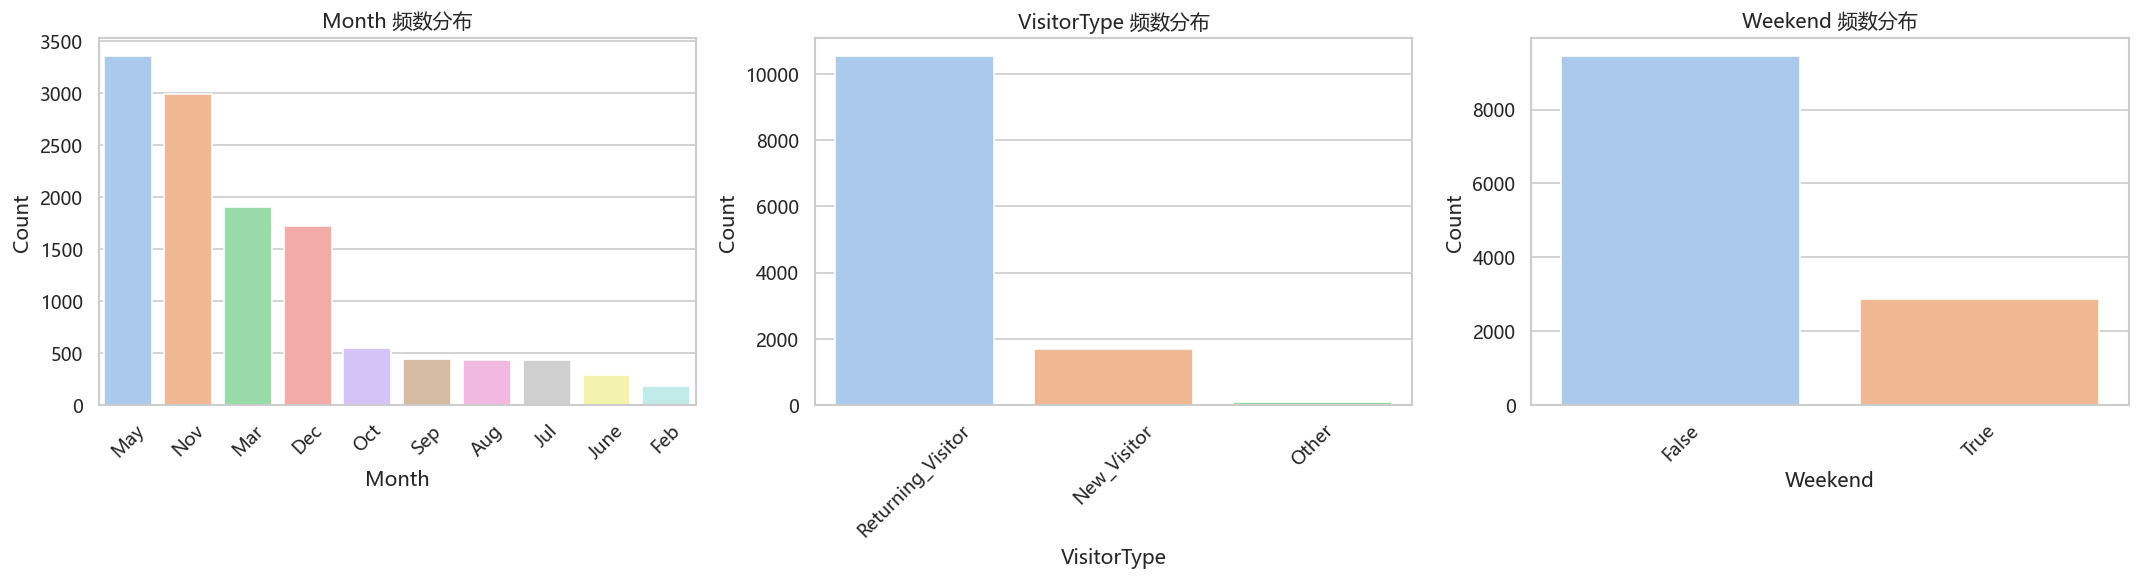

In [11]:
cat_cols = ["Month", "VisitorType", "Weekend"]
existing_cat_cols = [c for c in cat_cols if c in df.columns]
missing_cat_cols = [c for c in cat_cols if c not in df.columns]

if missing_cat_cols:
    print(f"以下类别列不存在，将跳过: {missing_cat_cols}")

for col in existing_cat_cols:
    print(f"\n=== {col} 频数统计 ===")
    counts = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
    summary = pd.DataFrame({"count": counts, "ratio_percent": ratio})
    display(summary)

if existing_cat_cols:
    n = len(existing_cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, existing_cat_cols):
        order = df[col].value_counts(dropna=False).index
        sns.countplot(data=df, x=col, order=order, ax=ax, palette="pastel")
        ax.set_title(f"{col} 频数分布")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### e. 相关性热力图
计算数值特征的相关系数矩阵并绘制热力图

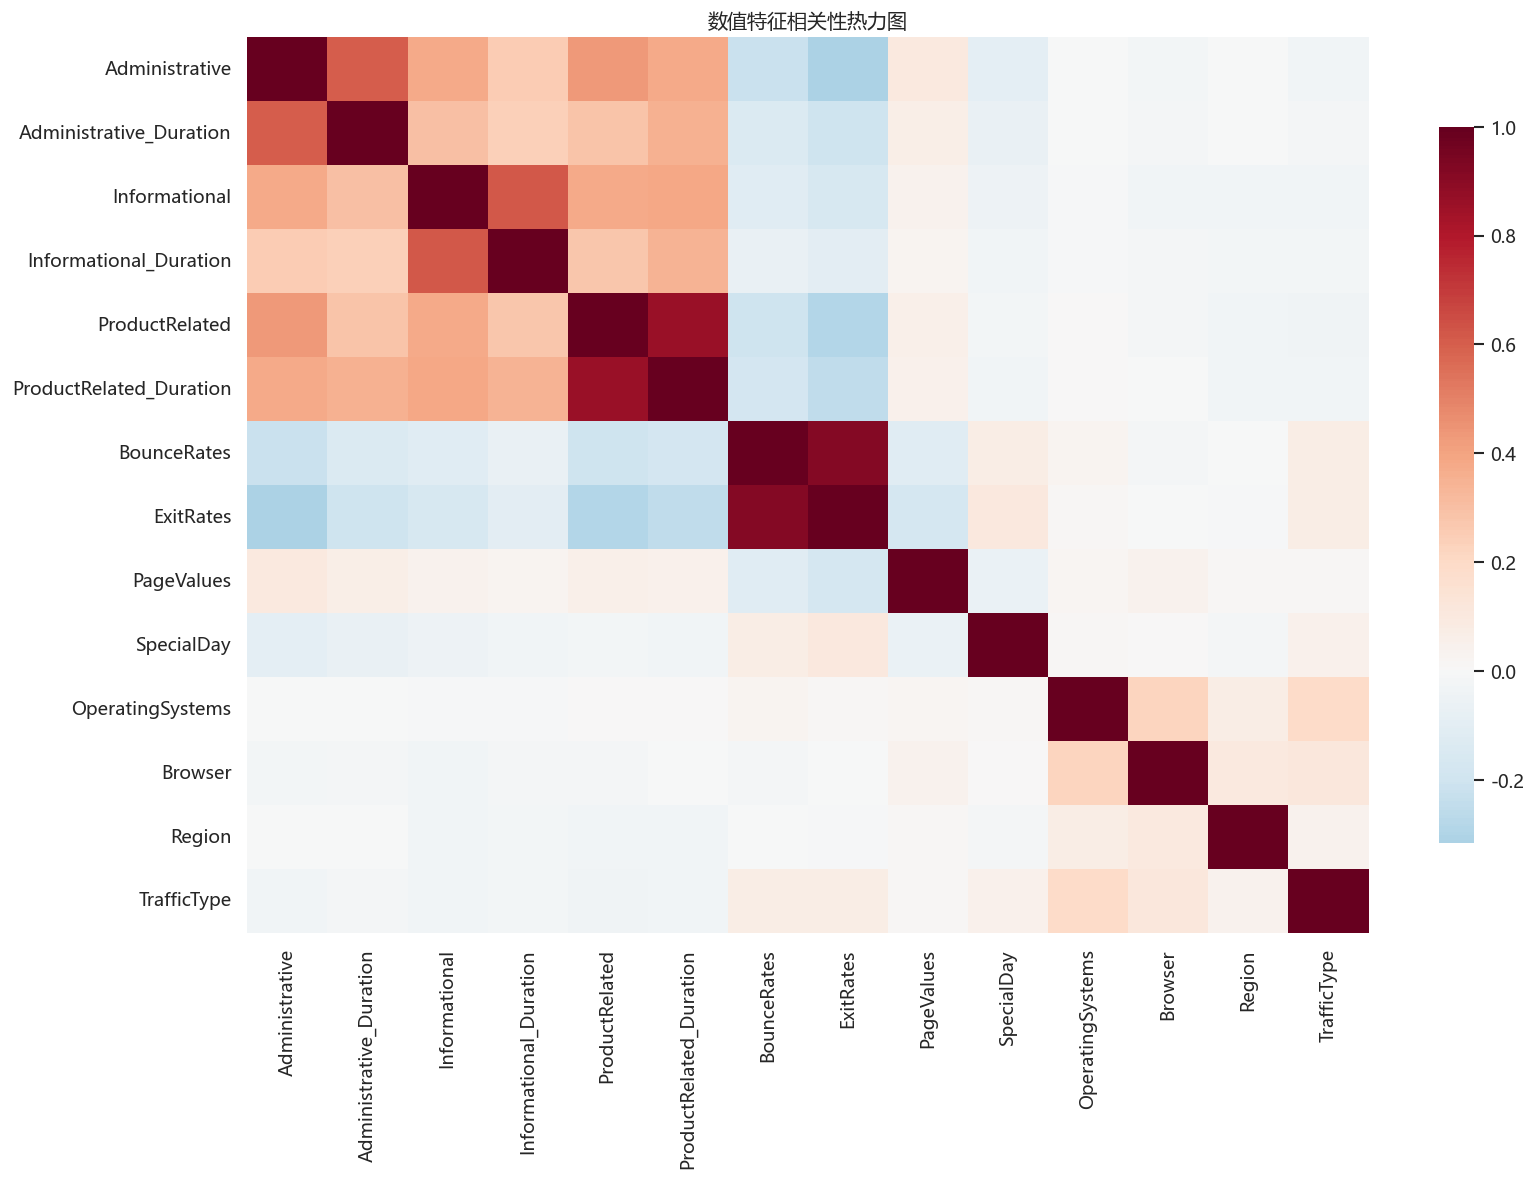

In [12]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    square=False,
    cbar_kws={"shrink": 0.8}
)
plt.title("数值特征相关性热力图")
plt.tight_layout()
plt.show()

## Part 2: 数据预处理

### a. 类别特征编码
使用 `pd.get_dummies` 对指定类别列进行独热编码，使用 `drop_first=True` 丢弃每组的第一个哑变量，避免完全多重共线性（虚拟变量陷阱）。

In [13]:
# 目标变量与特征拆分
y = df["Revenue"].astype(int)
X = df.drop(columns=["Revenue"]).copy()

# 类别特征编码
cat_cols_to_encode = [
    "Month", "VisitorType", "Weekend",
    "OperatingSystems", "Browser", "Region", "TrafficType"
]
existing_cat_cols = [c for c in cat_cols_to_encode if c in X.columns]
missing_cat_cols = [c for c in cat_cols_to_encode if c not in X.columns]

if missing_cat_cols:
    print(f"以下指定类别列不存在，将自动跳过: {missing_cat_cols}")

for col in existing_cat_cols:
    X[col] = X[col].astype(str)

X_encoded = pd.get_dummies(X, columns=existing_cat_cols, drop_first=True)
print(f"编码后特征维度: {X_encoded.shape}")
display(X_encoded.head())

编码后特征维度: (12330, 68)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,TrafficType_19,TrafficType_2,TrafficType_20,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,False,True,False,False,False,False,False,False,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,False,False,False,True,False,False,False,False,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,False,False,False,False,True,False,False,False,False,False


### b. 训练集/测试集划分
按照 80/20 划分数据集，并使用 `stratify=y` 保持目标变量类别比例一致。

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["RANDOM_SEED"],
    stratify=y
)

print(f"X_train 形状: {X_train.shape}, X_test 形状: {X_test.shape}")
print("\n原始训练集类别分布:")
display(y_train.value_counts().sort_index().to_frame(name="count"))

X_train 形状: (9864, 68), X_test 形状: (2466, 68)

原始训练集类别分布:


,count
Revenue,
0,8338
1,1526


### c. 特征标准化
使用 `StandardScaler` 对特征做标准化，分别准备监督学习（SVM）与聚类（K-Means）使用的数据。

In [15]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# 注：K-Means 用于探索时，严格在训练集上完成模型选择与拟合，避免测试集渗入
# 聚类标签通过分别 predict 获得，PCA 也仅 fit 训练集（见 Section 3b）

print("标准化完成：")
print(f"X_train_scaled 形状: {X_train_scaled.shape}")
print(f"X_test_scaled 形状: {X_test_scaled.shape}")

标准化完成：
X_train_scaled 形状: (9864, 68)
X_test_scaled 形状: (2466, 68)


### d. 处理类别不平衡
Revenue 正负样本比约 15:85，采用 `class_weight='balanced'` 让分类器在损失函数层面自动加权少数类，避免对训练集做过采样或欠采样。

In [16]:
# 类别不平衡处理策略：统一采用 class_weight='balanced'
# 理由：
#   1) 决策树/随机森林/SVM 均原生支持，无需对训练集做过采样
#   2) 不改变训练集大小，交叉验证与评估更干净
#   3) 实现简单，避免合成样本带来的偏差风险
class_weight_option = "balanced"

print("原始训练集类别分布:")
display(y_train.value_counts().sort_index().to_frame(name="count"))
print(f"分类模型类权重参数: class_weight='{class_weight_option}'")

原始训练集类别分布:


,count
Revenue,
0,8338
1,1526


分类模型类权重参数: class_weight='balanced'


## Part 3: 无监督学习：K-Means 聚类
围绕 K 值选择、聚类可视化、簇画像解释，并尝试将聚类标签作为监督学习的新特征。

### a. 用肘部法则与轮廓系数评估 K 值

K 值评估抽样样本量(仅训练集): 5000
肘部法则数据（SSE）：


,k,SSE
0,2,312170.294170
1,3,299890.911360
2,4,289983.540989
3,5,288302.795263
4,6,276932.836348



轮廓系数数据：


,k,silhouette_score
0,2,0.077263
1,3,0.085279
2,4,0.086672
3,5,0.082188
4,6,0.077678



全局最高轮廓系数对应 K: 4
在 K=3 与 K=4 中，最终选择 K: 4


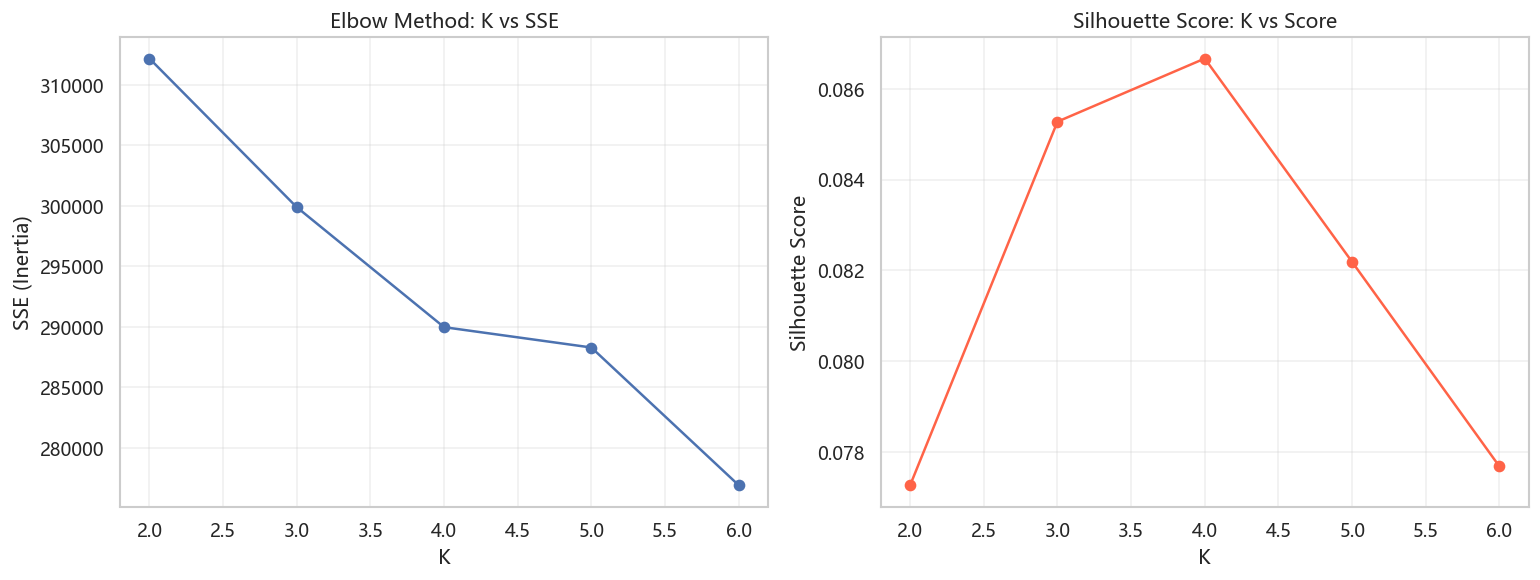

In [17]:
k_values = [2, 3, 4, 5, 6]

# K 值选择严格仅基于训练集，避免测试集信息渗入
k_eval_size = min(5000, len(X_train_scaled))
X_k_eval = X_train_scaled.sample(n=k_eval_size, random_state=CONFIG["RANDOM_SEED"])

sse_scores = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=CONFIG["RANDOM_SEED"], n_init=20)
    labels_k = km.fit_predict(X_k_eval)
    sse_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(X_k_eval, labels_k))

elbow_df = pd.DataFrame({"k": k_values, "SSE": sse_scores})
sil_df = pd.DataFrame({"k": k_values, "silhouette_score": sil_scores})

sil_3 = sil_df.loc[sil_df["k"] == 3, "silhouette_score"].iloc[0]
sil_4 = sil_df.loc[sil_df["k"] == 4, "silhouette_score"].iloc[0]
best_k_sil = sil_df.loc[sil_df["silhouette_score"].idxmax(), "k"]

# 简约性原则：轮廓系数提升幅度 < 阈值时偏向更小的 K
# 诊断显示 K=3→K=4 提升仅 ~0.001，而 K=3/K=4 均含同一个 5 样本极小簇，
# 增加 K 无实质收益，故以 0.005 为阈值优先选 K=3
SIL_GAIN_THRESHOLD = 0.005
selected_k = 3 if (sil_4 - sil_3) < SIL_GAIN_THRESHOLD else 4

print(f"K 值评估抽样样本量(仅训练集): {k_eval_size}")
print("肘部法则数据（SSE）：")
display(elbow_df)
print("\n轮廓系数数据：")
display(sil_df)
print(f"\n全局最高轮廓系数对应 K: {best_k_sil}")
print(f"K=3→K=4 轮廓系数提升: {sil_4 - sil_3:.4f}（简约性阈值 {SIL_GAIN_THRESHOLD}）")
print(f"简约性原则最终选择 K: {selected_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(elbow_df["k"], elbow_df["SSE"], marker="o")
axes[0].set_title("Elbow Method: K vs SSE")
axes[0].set_xlabel("K")
axes[0].set_ylabel("SSE (Inertia)")
axes[0].grid(alpha=0.3)

axes[1].plot(sil_df["k"], sil_df["silhouette_score"], marker="o", color="tomato")
axes[1].set_title("Silhouette Score: K vs Score")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### b. 使用选定的 K 进行聚类，并用 PCA 降维到 2D 可视化

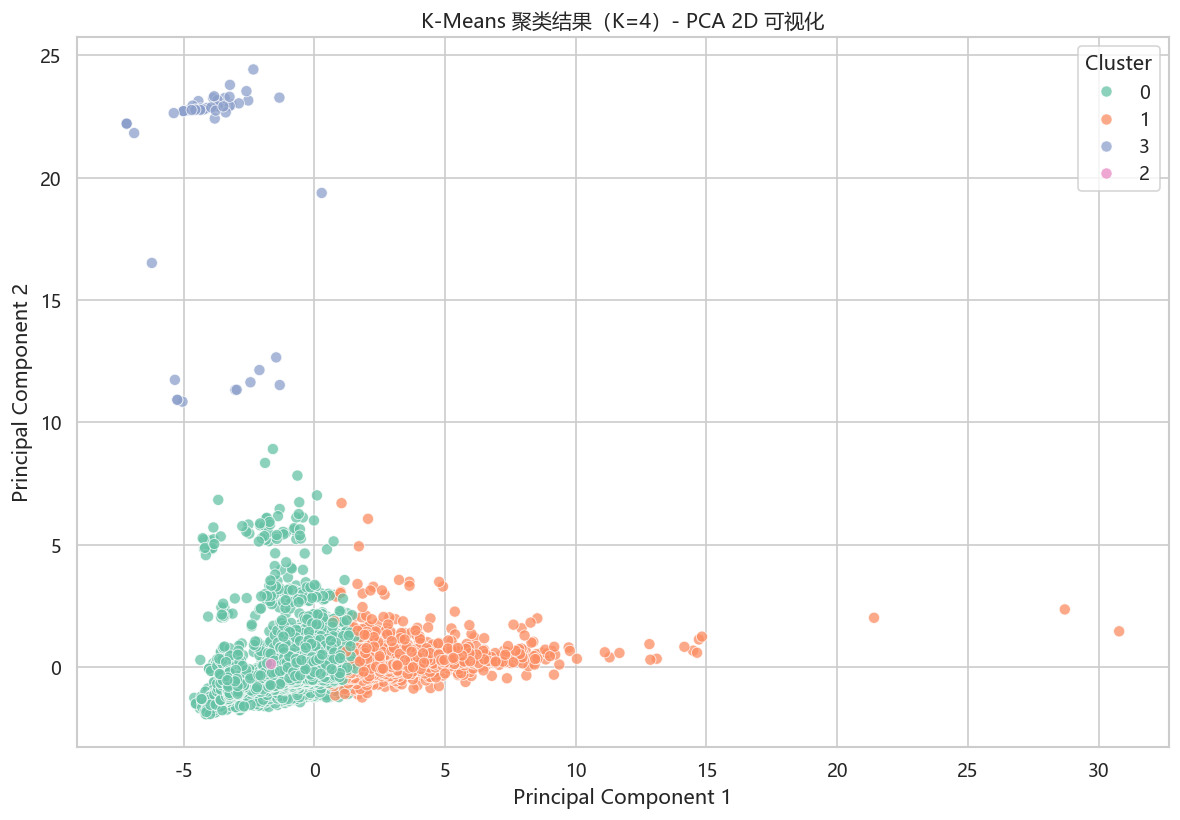

PCA 前两主成分累计解释方差比: 9.99%

各簇样本量：


,count
Cluster,
0,10233
1,2028
2,6
3,63


In [18]:
kmeans_final = KMeans(n_clusters=selected_k, random_state=CONFIG["RANDOM_SEED"], n_init=20)
# 只在训练集上 fit，杜绝测试集信息渗入簇中心
kmeans_final.fit(X_train_scaled)

# ---- 分别对训练/测试集 predict，避免全量拼接的数据泄漏 ----
cluster_train = pd.Series(
    kmeans_final.predict(X_train_scaled),
    index=X_train_scaled.index,
    name="Cluster"
)
cluster_test = pd.Series(
    kmeans_final.predict(X_test_scaled),
    index=X_test_scaled.index,
    name="Cluster"
)
cluster_labels = pd.concat([cluster_train, cluster_test]).sort_index()

# 保留一个带簇标签的数据副本，避免污染原始输入
profile_df = df.copy()
profile_df["Cluster"] = cluster_labels

# ---- PCA 只在训练集上 fit，然后分别 transform 两个集合 ----
pca = PCA(n_components=2, random_state=CONFIG["RANDOM_SEED"])
pca.fit(X_train_scaled)                              # fit 仅用训练集
X_train_pca = pca.transform(X_train_scaled)         # transform 训练集
X_test_pca = pca.transform(X_test_scaled)           # transform 测试集
explained = pca.explained_variance_ratio_.sum()

# ---- 可视化：拼接已转换的 PCA 数据（转换矩阵来自训练集，不再污染） ----
plot_train = pd.DataFrame(X_train_pca, columns=["PC1", "PC2"], index=X_train_scaled.index)
plot_train["Cluster"] = cluster_train.astype(str)
plot_train["Split"] = "Train"

plot_test = pd.DataFrame(X_test_pca, columns=["PC1", "PC2"], index=X_test_scaled.index)
plot_test["Cluster"] = cluster_test.astype(str)
plot_test["Split"] = "Test"

plot_df = pd.concat([plot_train, plot_test]).sort_index()
plot_df["Revenue"] = y.astype(int).map({0: "No", 1: "Yes"})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.75,
    s=45
)
plt.title(f"K-Means 聚类结果（K={selected_k}）- PCA 2D 可视化")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print(f"PCA 前两主成分累计解释方差比: {explained:.2%}")
print("\n各簇样本量：")
cluster_size = profile_df["Cluster"].value_counts().sort_index().to_frame(name="count")
display(cluster_size)

### c. 簇画像分析：比较关键特征均值，识别高意向/浏览型/跳出型用户

In [19]:
# ---- 画像仅基于训练集，避免测试集统计量混入 ----
profile_df = df.loc[X_train.index].copy()
profile_df["Cluster"] = cluster_train

key_features = [
    "PageValues", "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "Administrative_Duration",
    "Informational_Duration", "Revenue"
]
key_features = [c for c in key_features if c in profile_df.columns]

cluster_profile = profile_df.groupby("Cluster")[key_features].mean().round(4)
cluster_median  = profile_df.groupby("Cluster")[key_features].median().round(4)
print("各簇关键特征均值（仅训练集）：")
display(cluster_profile)
print("\n各簇关键特征中位数（仅训练集）：")
display(cluster_median)

cluster_ids = cluster_profile.index.tolist()
remaining = cluster_ids.copy()

# 高意向：Revenue 均值最高
high_intent_cluster = cluster_profile["Revenue"].idxmax()
remaining.remove(high_intent_cluster)

# 跳出型：在剩余簇中 BounceRates 均值最高
if remaining:
    bounce_cluster = cluster_profile.loc[remaining, "BounceRates"].idxmax()
    remaining.remove(bounce_cluster)
else:
    bounce_cluster = high_intent_cluster

name_map = {high_intent_cluster: "高意向用户"}
if bounce_cluster not in name_map:
    name_map[bounce_cluster] = "跳出型用户"

if remaining:
    name_map[remaining[0]] = "浏览型用户"
for extra_c in remaining[1:]:
    name_map[extra_c] = "混合探索用户"

summary_rows = []
for cid in cluster_ids:
    row = {
        "Cluster": cid,
        "用户类型": name_map.get(cid, "其他"),
        "样本数": int((profile_df["Cluster"] == cid).sum()),
        "Revenue均值": float(cluster_profile.loc[cid, "Revenue"]),
        "Revenue中位数": float(cluster_median.loc[cid, "Revenue"])
    }
    if "PageValues" in cluster_profile.columns:
        row["PageValues均值"]   = float(cluster_profile.loc[cid, "PageValues"])
        row["PageValues中位数"] = float(cluster_median.loc[cid, "PageValues"])
    if "BounceRates" in cluster_profile.columns:
        row["BounceRates均值"]   = float(cluster_profile.loc[cid, "BounceRates"])
        row["BounceRates中位数"] = float(cluster_median.loc[cid, "BounceRates"])
    if "ExitRates" in cluster_profile.columns:
        row["ExitRates均值"]   = float(cluster_profile.loc[cid, "ExitRates"])
        row["ExitRates中位数"] = float(cluster_median.loc[cid, "ExitRates"])
    summary_rows.append(row)

cluster_interpretation = pd.DataFrame(summary_rows).sort_values("Cluster").reset_index(drop=True)
print("\n簇画像解释（仅训练集统计）：")
display(cluster_interpretation)

各簇关键特征均值（仅训练集）：


,PageValues,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,Administrative_Duration,Informational_Duration,Revenue
Cluster,,,,,,,,
0,4.9482,20.3328,740.2920,0.0256,0.0481,40.5904,6.5424,0.1282
1,10.4929,87.8432,3443.7315,0.0060,0.0192,285.2599,176.1534,0.2841
2,5.2377,13.2000,845.7200,0.0100,0.0356,29.4667,2.6000,0.2000
3,19.2503,10.6667,492.2530,0.0373,0.0555,68.1590,1.1481,0.2407



簇画像解释（仅训练集统计）：


,Cluster,用户类型,样本数,Revenue均值,PageValues均值,BounceRates均值,ExitRates均值
0,0,浏览型用户,8172,0.1282,4.9482,0.0256,0.0481
1,1,高意向用户,1633,0.2841,10.4929,0.0060,0.0192
2,2,混合探索用户,5,0.2000,5.2377,0.0100,0.0356
3,3,跳出型用户,54,0.2407,19.2503,0.0373,0.0555


In [ ]:
# ── 诊断：极小簇样本详查 & K=2/3/4 均衡性对比 ─────────────────────────────

# ── 诊断 1：当前 K 下各簇大小 + 极小簇原始特征 ──────────────────────────────
print("=" * 65)
print(f"K={selected_k}  训练集各簇大小")
print("=" * 65)

cluster_sizes = cluster_train.value_counts().sort_index()
for c, n in cluster_sizes.items():
    print(f"  Cluster {c}: {n:>5} 样本  ({n / len(cluster_train) * 100:.2f}%)")

tiny_threshold = len(cluster_train) * 0.01          # 小于 1% 视为极小簇
tiny_clusters = cluster_sizes[cluster_sizes < tiny_threshold].index.tolist()
print(f"\n极小簇（占比 < 1%）：{tiny_clusters}")

for c in tiny_clusters:
    sub = profile_df[profile_df["Cluster"] == c][key_features]
    print(f"\n── Cluster {c}（训练集 {len(sub)} 个样本）──")
    display(sub)
    if len(sub) > 5:
        print("描述统计：")
        display(sub.describe().round(4))

# ── 诊断 2：K=2 / 3 / 4 轮廓系数 vs 最小簇占比（全量训练集） ───────────────
print()
print("=" * 65)
print("K=2 / 3 / 4  轮廓系数 vs 最小簇占比（全量训练集）")
print("=" * 65)

comparison_rows = []
for k in [2, 3, 4]:
    if k == selected_k:
        labels_tmp = cluster_train.values          # 复用已有结果
    else:
        km_tmp = KMeans(n_clusters=k, random_state=CONFIG["RANDOM_SEED"], n_init=20)
        labels_tmp = km_tmp.fit_predict(X_train_scaled)
    counts = pd.Series(labels_tmp).value_counts()
    min_count = int(counts.min())
    min_pct = round(min_count / len(labels_tmp) * 100, 2)
    sil = float(sil_df.loc[sil_df["k"] == k, "silhouette_score"].iloc[0])
    comparison_rows.append({
        "K": k,
        "轮廓系数": round(sil, 4),
        "各簇样本数": str(dict(counts.sort_index())),
        "最小簇样本数": min_count,
        "最小簇占比(%)": min_pct,
    })

comp_df = pd.DataFrame(comparison_rows)
display(comp_df[["K", "轮廓系数", "最小簇样本数", "最小簇占比(%)"]])
print()
for row in comparison_rows:
    print(f"K={row['K']}  轮廓系数={row['轮廓系数']}  各簇大小={row['各簇样本数']}")

### d. 将聚类标签作为新特征加入分类模型

In [20]:
# ---- 直接使用分别 predict 的结果，无需二次索引切片 ----
Xc_train = X_train.copy()
Xc_train["Cluster"] = cluster_train.astype(int)

Xc_test = X_test.copy()
Xc_test["Cluster"] = cluster_test.astype(int)

# yc_train / yc_test 直接用对应的 y_train / y_test
yc_train = y_train
yc_test = y_test

rf_base = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_option,
    n_jobs=-1
)
rf_plus = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight=class_weight_option,
    n_jobs=-1
)

base_cv = cross_val_score(rf_base, X_train, y_train, cv=5, scoring="f1")
plus_cv = cross_val_score(rf_plus, Xc_train, yc_train, cv=5, scoring="f1")

rf_base.fit(X_train, y_train)
rf_plus.fit(Xc_train, yc_train)
base_test_f1 = f1_score(y_test, rf_base.predict(X_test))
plus_test_f1 = f1_score(yc_test, rf_plus.predict(Xc_test))

print("随机森林（是否加入 Cluster 特征）对比：")
comparison_df = pd.DataFrame({
    "方案": ["Baseline（无聚类特征）", "Plus（加入聚类特征）"],
    "CV-F1(mean)": [base_cv.mean(), plus_cv.mean()],
    "CV-F1(std)": [base_cv.std(), plus_cv.std()],
    "Test-F1": [base_test_f1, plus_test_f1]
})
display(comparison_df)

if plus_test_f1 >= base_test_f1:
    print("加入聚类特征后，测试集 F1 提升或持平。")
else:
    print("加入聚类特征后，测试集 F1 略有下降，可进一步调参与特征工程。")

随机森林（是否加入 Cluster 特征）对比：


,方案,CV-F1(mean),CV-F1(std),Test-F1
0,Baseline（无聚类特征）,0.627462,0.016787,0.597774
1,Plus（加入聚类特征）,0.635033,0.020054,0.603175


加入聚类特征后，测试集 F1 提升或持平。


## Part 4: 监督学习 - 四个分类模型

按照 README 要求训练 4 个分类器（GaussianNB / DecisionTree / RandomForest / SVC-RBF），每个模型用 5 折交叉验证评估，随机森林与 SVM 额外通过 `GridSearchCV` 调参。最终把训练好的模型与 CV 结果分别存入 `models` 和 `cv_results`，供 Section 5（评估对比）、Section 6（特征重要性 / 决策树可视化）和 Section 7（最终推荐）直接复用。

数据使用约定：
- 朴素贝叶斯、SVM：使用标准化后的 `X_train_scaled / X_test_scaled`
- 决策树、随机森林：使用未标准化的 `X_train / X_test`（树模型对量纲不敏感）
- 统一沿用 Section 2 的 `class_weight="balanced"` 处理类别不平衡（GaussianNB 不支持该参数，保持默认先验）

In [21]:
# 统一结果容器 + 无泄漏交叉验证辅助函数
models = {}
cv_results = {}
cv_splitter = StratifiedKFold(
    n_splits=CONFIG["CV_FOLDS"],
    shuffle=True,
    random_state=CONFIG["RANDOM_SEED"]
)

def evaluate_cv(name, estimator, X, y, cv=cv_splitter, scoring=None):
    if scoring is None:
        scoring = CONFIG["SCORING_MAIN"]
    scores = cross_val_score(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "cv_mean": scores.mean(),
        "cv_std": scores.std(),
        "cv_scores": scores,
        "cv_scoring": scoring
    }
    print(f"{name:20s}  {cv.get_n_splits()}-fold CV {scoring} = {scores.mean():.4f} ± {scores.std():.4f}")
    return scores

### a. 朴素贝叶斯（GaussianNB）

In [22]:
# 用 Pipeline 把标准化封进 CV 流程，避免折间信息泄漏
# 注：GaussianNB 不支持 class_weight 参数，这里保持默认先验
nb_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])
evaluate_cv("Naive Bayes", nb_clf, X_train, y_train)

nb_clf.fit(X_train, y_train)
models["Naive Bayes"] = nb_clf
print("GaussianNB Pipeline 已拟合并存入 models['Naive Bayes']")

Naive Bayes           5-fold CV f1 = 0.2920 ± 0.0031
GaussianNB Pipeline 已拟合并存入 models['Naive Bayes']


### b. 决策树（DecisionTreeClassifier）

In [23]:
# ---- 决策树基线（未调参，用于参照） ----
dt_baseline = DecisionTreeClassifier(
    random_state=CONFIG["RANDOM_SEED"],
    class_weight=class_weight_option
)
evaluate_cv("Decision Tree (base)", dt_baseline, X_train, y_train)

# ---- GridSearchCV 调参 ----
dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(
        random_state=CONFIG["RANDOM_SEED"],
        class_weight=class_weight_option
    ),
    param_grid=dt_param_grid,
    cv=cv_splitter,
    scoring=CONFIG["SCORING_MAIN"],
    n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print(f"DecisionTree Best Params: {dt_grid.best_params_}")
scoring_name = CONFIG["SCORING_MAIN"]
print(f"DecisionTree Best CV {scoring_name}: {dt_grid.best_score_:.4f}")

dt_best = dt_grid.best_estimator_
cv_results["Decision Tree"] = {
    "cv_mean": dt_grid.best_score_,
    "cv_std": float(dt_grid.cv_results_["std_test_score"][dt_grid.best_index_]),
    "cv_scores": None,
    "best_params": dt_grid.best_params_,
    "cv_scoring": CONFIG["SCORING_MAIN"]
}
models["Decision Tree"] = dt_best
print("Decision Tree（调参后）已存入 models['Decision Tree']")

Decision Tree (base)  5-fold CV f1 = 0.5641 ± 0.0080
DecisionTree Best Params: {'max_depth': 5, 'min_samples_leaf': 20, 'min_samples_split': 2}
DecisionTree Best CV f1: 0.6327
Decision Tree（调参后）已存入 models['Decision Tree']


### c. 随机森林（RandomForestClassifier） + GridSearchCV

In [24]:
# 基线：使用默认配置做一次 5 折 CV 作为调参前参考
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=CONFIG["RANDOM_SEED"],
    class_weight=class_weight_option,
    n_jobs=-1
)
evaluate_cv("Random Forest (base)", rf_baseline, X_train, y_train)

# GridSearchCV 调参（刻意保持小规模以控制运行时间）
rf_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=CONFIG["RANDOM_SEED"],
        class_weight=class_weight_option,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=cv_splitter,
    scoring=CONFIG["SCORING_MAIN"],
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"\nRandomForest Best Params: {rf_grid.best_params_}")
print(f"RandomForest Best CV {CONFIG['SCORING_MAIN']}: {rf_grid.best_score_:.4f}")

# 用调参后的最佳估计器覆盖 cv_results["Random Forest"]
rf_best = rf_grid.best_estimator_
cv_results["Random Forest"] = {
    "cv_mean": rf_grid.best_score_,
    "cv_std": float(rf_grid.cv_results_["std_test_score"][rf_grid.best_index_]),
    "cv_scores": None,
    "best_params": rf_grid.best_params_,
    "cv_scoring": CONFIG["SCORING_MAIN"]
}
models["Random Forest"] = rf_best
print("Random Forest（调参后）已存入 models['Random Forest']")

Random Forest (base)  5-fold CV f1 = 0.6166 ± 0.0232

RandomForest Best Params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 400}
RandomForest Best CV f1: 0.6741
Random Forest（调参后）已存入 models['Random Forest']


### d. 支持向量机（SVC RBF 核） + GridSearchCV

In [25]:
# 用 Pipeline 把标准化封进 CV 流程，避免折间信息泄漏
svm_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        class_weight=class_weight_option,
        probability=True,
        random_state=CONFIG["RANDOM_SEED"]
    ))
])
evaluate_cv("SVM-RBF (base)", svm_baseline, X_train, y_train)

# GridSearchCV：小规模网格，兼顾效果与运行时间
svm_param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.01, 0.001]
}
svm_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(
            kernel="rbf",
            class_weight=class_weight_option,
            probability=True,
            random_state=CONFIG["RANDOM_SEED"]
        ))
    ]),
    param_grid=svm_param_grid,
    cv=cv_splitter,
    scoring=CONFIG["SCORING_MAIN"],
    n_jobs=-1
)
svm_grid.fit(X_train, y_train)

print(f"\nSVM-RBF Best Params: {svm_grid.best_params_}")
print(f"SVM-RBF Best CV {CONFIG['SCORING_MAIN']}: {svm_grid.best_score_:.4f}")

svm_best = svm_grid.best_estimator_
cv_results["SVM (RBF)"] = {
    "cv_mean": svm_grid.best_score_,
    "cv_std": float(svm_grid.cv_results_["std_test_score"][svm_grid.best_index_]),
    "cv_scores": None,
    "best_params": svm_grid.best_params_,
    "cv_scoring": CONFIG["SCORING_MAIN"]
}
models["SVM (RBF)"] = svm_best
print("SVM（调参后）已存入 models['SVM (RBF)']")

SVM-RBF (base)        5-fold CV f1 = 0.6105 ± 0.0166

SVM-RBF Best Params: {'svc__C': 10, 'svc__gamma': 0.001}
SVM-RBF Best CV f1: 0.6547
SVM（调参后）已存入 models['SVM (RBF)']


### e. 四模型 5 折交叉验证结果汇总

In [26]:
# 汇总四个最终模型（调参后）在 5 折 CV 上的表现
final_model_names = ["Naive Bayes", "Decision Tree", "Random Forest", "SVM (RBF)"]
summary_rows = []
for name in final_model_names:
    info = cv_results[name]
    summary_rows.append({
        "Model": name,
        "CV F1 (mean)": round(info["cv_mean"], 4),
        "CV F1 (std)": round(info["cv_std"], 4),
        "Best Params": info.get("best_params", "-")
    })

cv_summary_df = pd.DataFrame(summary_rows).sort_values(
    "CV F1 (mean)", ascending=False
).reset_index(drop=True)

print("Section 4 —— 四个模型 5 折交叉验证汇总：")
display(cv_summary_df)

print("\n已训练并缓存的模型：")
for name, m in models.items():
    print(f"  - {name}: {type(m).__name__}")

Section 4 —— 四个模型 5 折交叉验证汇总：


,Model,CV F1 (mean),CV F1 (std),Best Params
0,Random Forest,0.6741,0.0144,"{'max_depth': 20, 'min_samples_split': 5, 'n_e..."
1,SVM (RBF),0.6547,0.0220,"{'svc__C': 10, 'svc__gamma': 0.001}"
2,Decision Tree,0.6327,0.0133,"{'max_depth': 5, 'min_samples_leaf': 20, 'min_..."
3,Naive Bayes,0.2920,0.0031,-



已训练并缓存的模型：
  - Naive Bayes: Pipeline
  - Decision Tree: DecisionTreeClassifier
  - Random Forest: RandomForestClassifier
  - SVM (RBF): Pipeline


## Part 5: 模型评估与对比

在测试集（`X_test / X_test_scaled`）上评估 Section 4 训练好的 4 个模型：
- 计算 Accuracy / Precision / Recall / F1-Score（针对正类 Revenue=1）
- 并排展示 4 个模型的混淆矩阵热力图
- 把 4 条 ROC 曲线画在同一张图上对比
- 最终用汇总表统一对比，并打出推荐模型

In [27]:
# Section 5 补充导入（主导入已在 cell 1 完成）
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score
)

# 统一定义每个模型对应的测试数据
# Naive Bayes/SVM 现为带 StandardScaler 的 Pipeline，直接使用 X_test
# Decision Tree/Random Forest 本身用未标准化特征

test_data_map = {
    "Naive Bayes":   X_test,
    "Decision Tree": X_test,
    "Random Forest": X_test,
    "SVM (RBF)":     X_test,
}

# 容器：存放每个模型的预测结果，避免重复 predict
predictions = {}
probabilities = {}
test_metrics = {}

for name, model in models.items():
    X_eval = test_data_map[name]
    y_pred = model.predict(X_eval)
    predictions[name] = y_pred
    # predict_proba：用于 ROC。NB / RF / SVC(probability=True) 都支持，决策树也支持
    if hasattr(model, "predict_proba"):
        probabilities[name] = model.predict_proba(X_eval)[:, 1]
    else:
        probabilities[name] = None

    test_metrics[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "F1":        f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    }

print("各模型已完成测试集预测与指标计算。")

各模型已完成测试集预测与指标计算。


### a. 各模型 Accuracy / Precision / Recall / F1-Score

In [28]:
# 为每个模型打印 classification_report，随后汇总核心指标到一张表
for name in models.keys():
    print(f"===== {name} =====")
    print(classification_report(
        y_test,
        predictions[name],
        target_names=["No Revenue", "Revenue"],
        digits=4,
        zero_division=0
    ))

metrics_df = pd.DataFrame(test_metrics).T.round(4)
metrics_df.index.name = "Model"
print("四模型测试集核心指标（针对正类 Revenue=1）：")
display(metrics_df)

===== Naive Bayes =====
              precision    recall  f1-score   support

  No Revenue     0.9727    0.1195    0.2128      2084
     Revenue     0.1697    0.9817    0.2894       382

    accuracy                         0.2530      2466
   macro avg     0.5712    0.5506    0.2511      2466
weighted avg     0.8483    0.2530    0.2247      2466

===== Decision Tree =====
              precision    recall  f1-score   support

  No Revenue     0.9668    0.8373    0.8974      2084
     Revenue     0.4871    0.8429    0.6174       382

    accuracy                         0.8382      2466
   macro avg     0.7269    0.8401    0.7574      2466
weighted avg     0.8925    0.8382    0.8540      2466

===== Random Forest =====
              precision    recall  f1-score   support

  No Revenue     0.9326    0.9424    0.9375      2084
     Revenue     0.6667    0.6283    0.6469       382

    accuracy                         0.8938      2466
   macro avg     0.7996    0.7853    0.7922      246

,Accuracy,Precision,Recall,F1
Model,,,,
Naive Bayes,0.2530,0.1697,0.9817,0.2894
Decision Tree,0.8382,0.4871,0.8429,0.6174
Random Forest,0.8938,0.6667,0.6283,0.6469
SVM (RBF),0.8719,0.5679,0.7225,0.6359


### b. 四个模型的混淆矩阵热力图（并排展示）

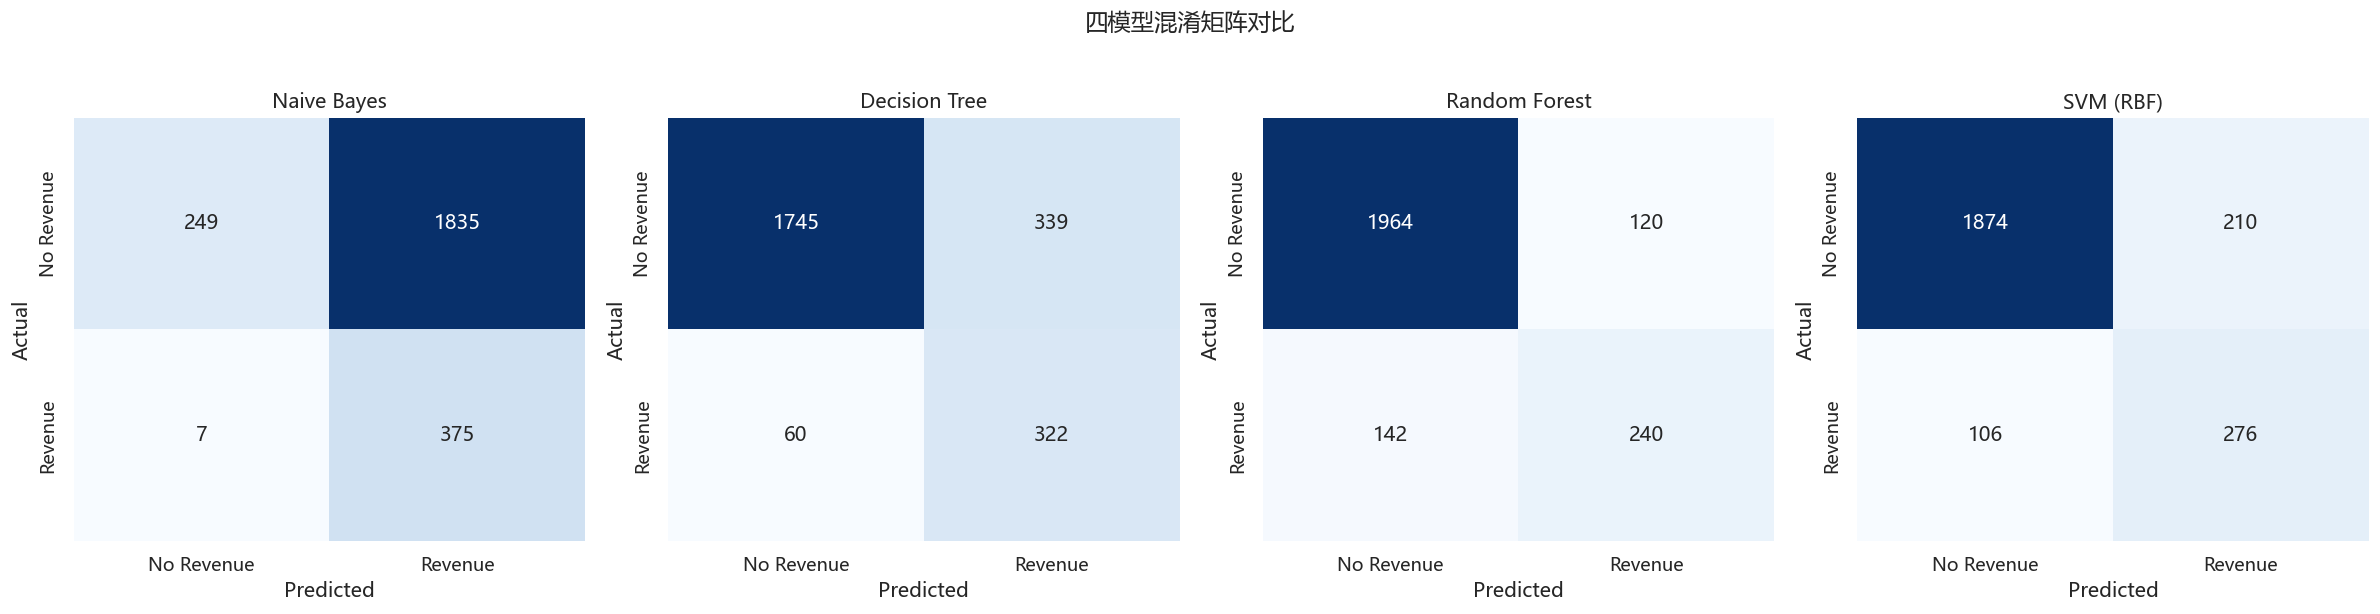

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Revenue", "Revenue"],
        yticklabels=["No Revenue", "Revenue"],
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("四模型混淆矩阵对比", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### c. 四条 ROC 曲线对比（同一张图）

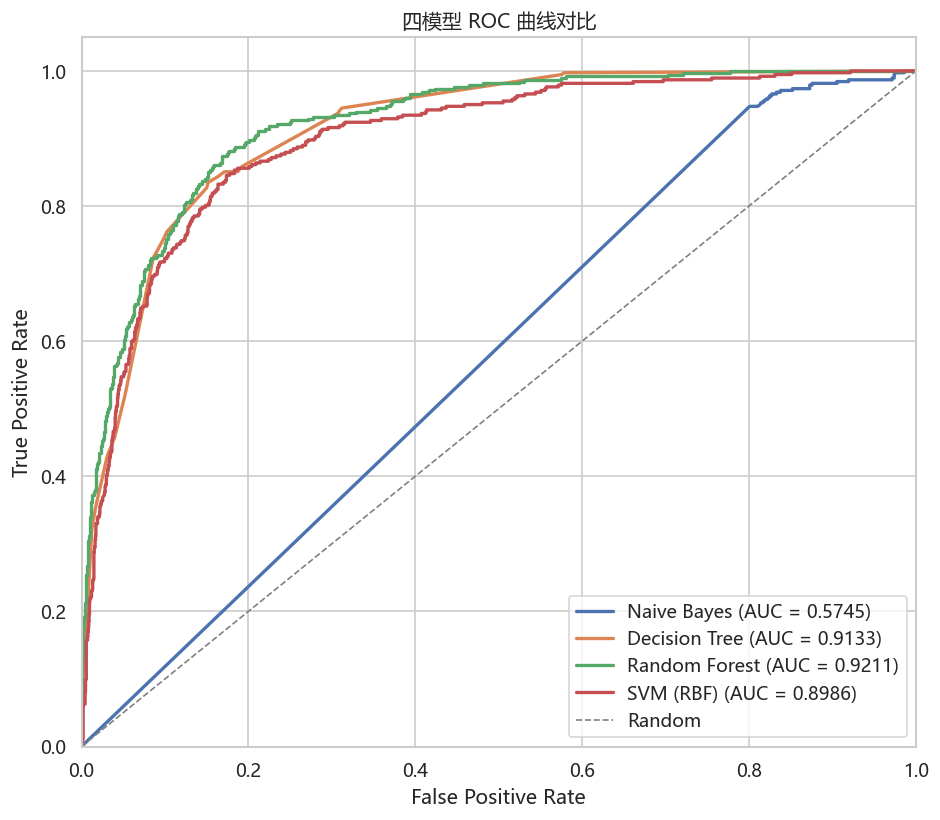

In [30]:
plt.figure(figsize=(8, 7))

roc_info = {}
for name, y_score in probabilities.items():
    if y_score is None:
        continue
    fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)
    roc_auc = auc(fpr, tpr)
    roc_info[name] = roc_auc
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("四模型 ROC 曲线对比")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 把 AUC 并入核心指标表，方便统一对比
for name, a in roc_info.items():
    test_metrics[name]["AUC"] = a

### d. 汇总对比表 + 推荐模型

In [31]:
# 同时整合 Section 4 的 CV 结果与 Section 5 的测试集指标
summary_rows = []
for name in models.keys():
    cv = cv_results.get(name, {})
    tm = test_metrics[name]
    summary_rows.append({
        "Model":     name,
        "CV F1":     round(cv.get("cv_mean", float("nan")), 4),
        "Test Acc":  round(tm["Accuracy"], 4),
        "Precision": round(tm["Precision"], 4),
        "Recall":    round(tm["Recall"], 4),
        "F1":        round(tm["F1"], 4),
        "AUC":       round(tm.get("AUC", float("nan")), 4),
    })

final_summary_df = pd.DataFrame(summary_rows).sort_values(
    "F1", ascending=False
).reset_index(drop=True)

print("Section 5 —— 四模型在测试集上的综合对比（按 F1 降序）：")
display(final_summary_df)

# 以 F1-Score 为主要选型依据（在类不平衡场景下比 Accuracy 更稳健）
best_row = final_summary_df.iloc[0]
print(f"\n>>> 当前最佳模型：{best_row['Model']}")
print(f"    Test Accuracy = {best_row['Test Acc']}")
print(f"    F1-Score      = {best_row['F1']}")
print(f"    AUC           = {best_row['AUC']}")

Section 5 —— 四模型在测试集上的综合对比（按 F1 降序）：


,Model,CV F1,Test Acc,Precision,Recall,F1,AUC
0,Random Forest,0.6741,0.8938,0.6667,0.6283,0.6469,0.9211
1,SVM (RBF),0.6547,0.8719,0.5679,0.7225,0.6359,0.8986
2,Decision Tree,0.6327,0.8382,0.4871,0.8429,0.6174,0.9133
3,Naive Bayes,0.2920,0.2530,0.1697,0.9817,0.2894,0.5745



>>> 当前最佳模型：Random Forest
    Test Accuracy = 0.8938
    F1-Score      = 0.6469
    AUC           = 0.9211


## Part 6: 特征重要性分析

- 基于调参后的随机森林模型绘制 `feature_importances_` 柱状图，识别对购买意向最具贡献的特征
- 使用 `plot_tree` 可视化决策树的前 3–4 层，帮助理解决策路径

### a. 随机森林特征重要性 Top-15

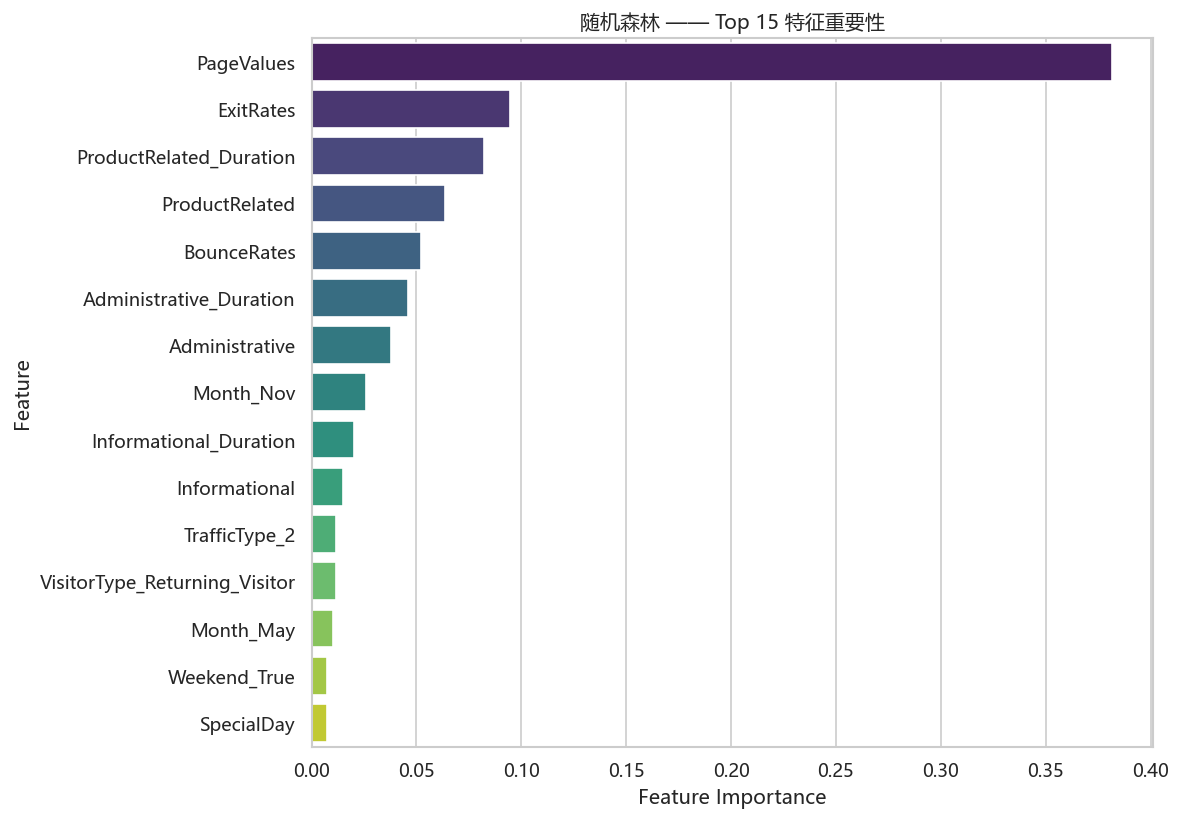

Top 15 特征重要性（随机森林）：


,importance
PageValues,0.3818
ExitRates,0.0944
ProductRelated_Duration,0.0822
ProductRelated,0.0637
BounceRates,0.0521
Administrative_Duration,0.0460
Administrative,0.0379
Month_Nov,0.0261
Informational_Duration,0.0202
Informational,0.0151


In [32]:
# Section 6 补充导入
from sklearn.tree import plot_tree

rf_model = models["Random Forest"]
feat_names = X_train.columns.tolist()

importances = pd.Series(
    rf_model.feature_importances_,
    index=feat_names,
    name="importance"
).sort_values(ascending=False)

top_n = 15
top_importances = importances.head(top_n)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=top_importances.values,
    y=top_importances.index,
    palette="viridis"
)
plt.title(f"随机森林 —— Top {top_n} 特征重要性")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print(f"Top {top_n} 特征重要性（随机森林）：")
display(top_importances.round(4).to_frame())

### b. 决策树可视化（前 3 层）

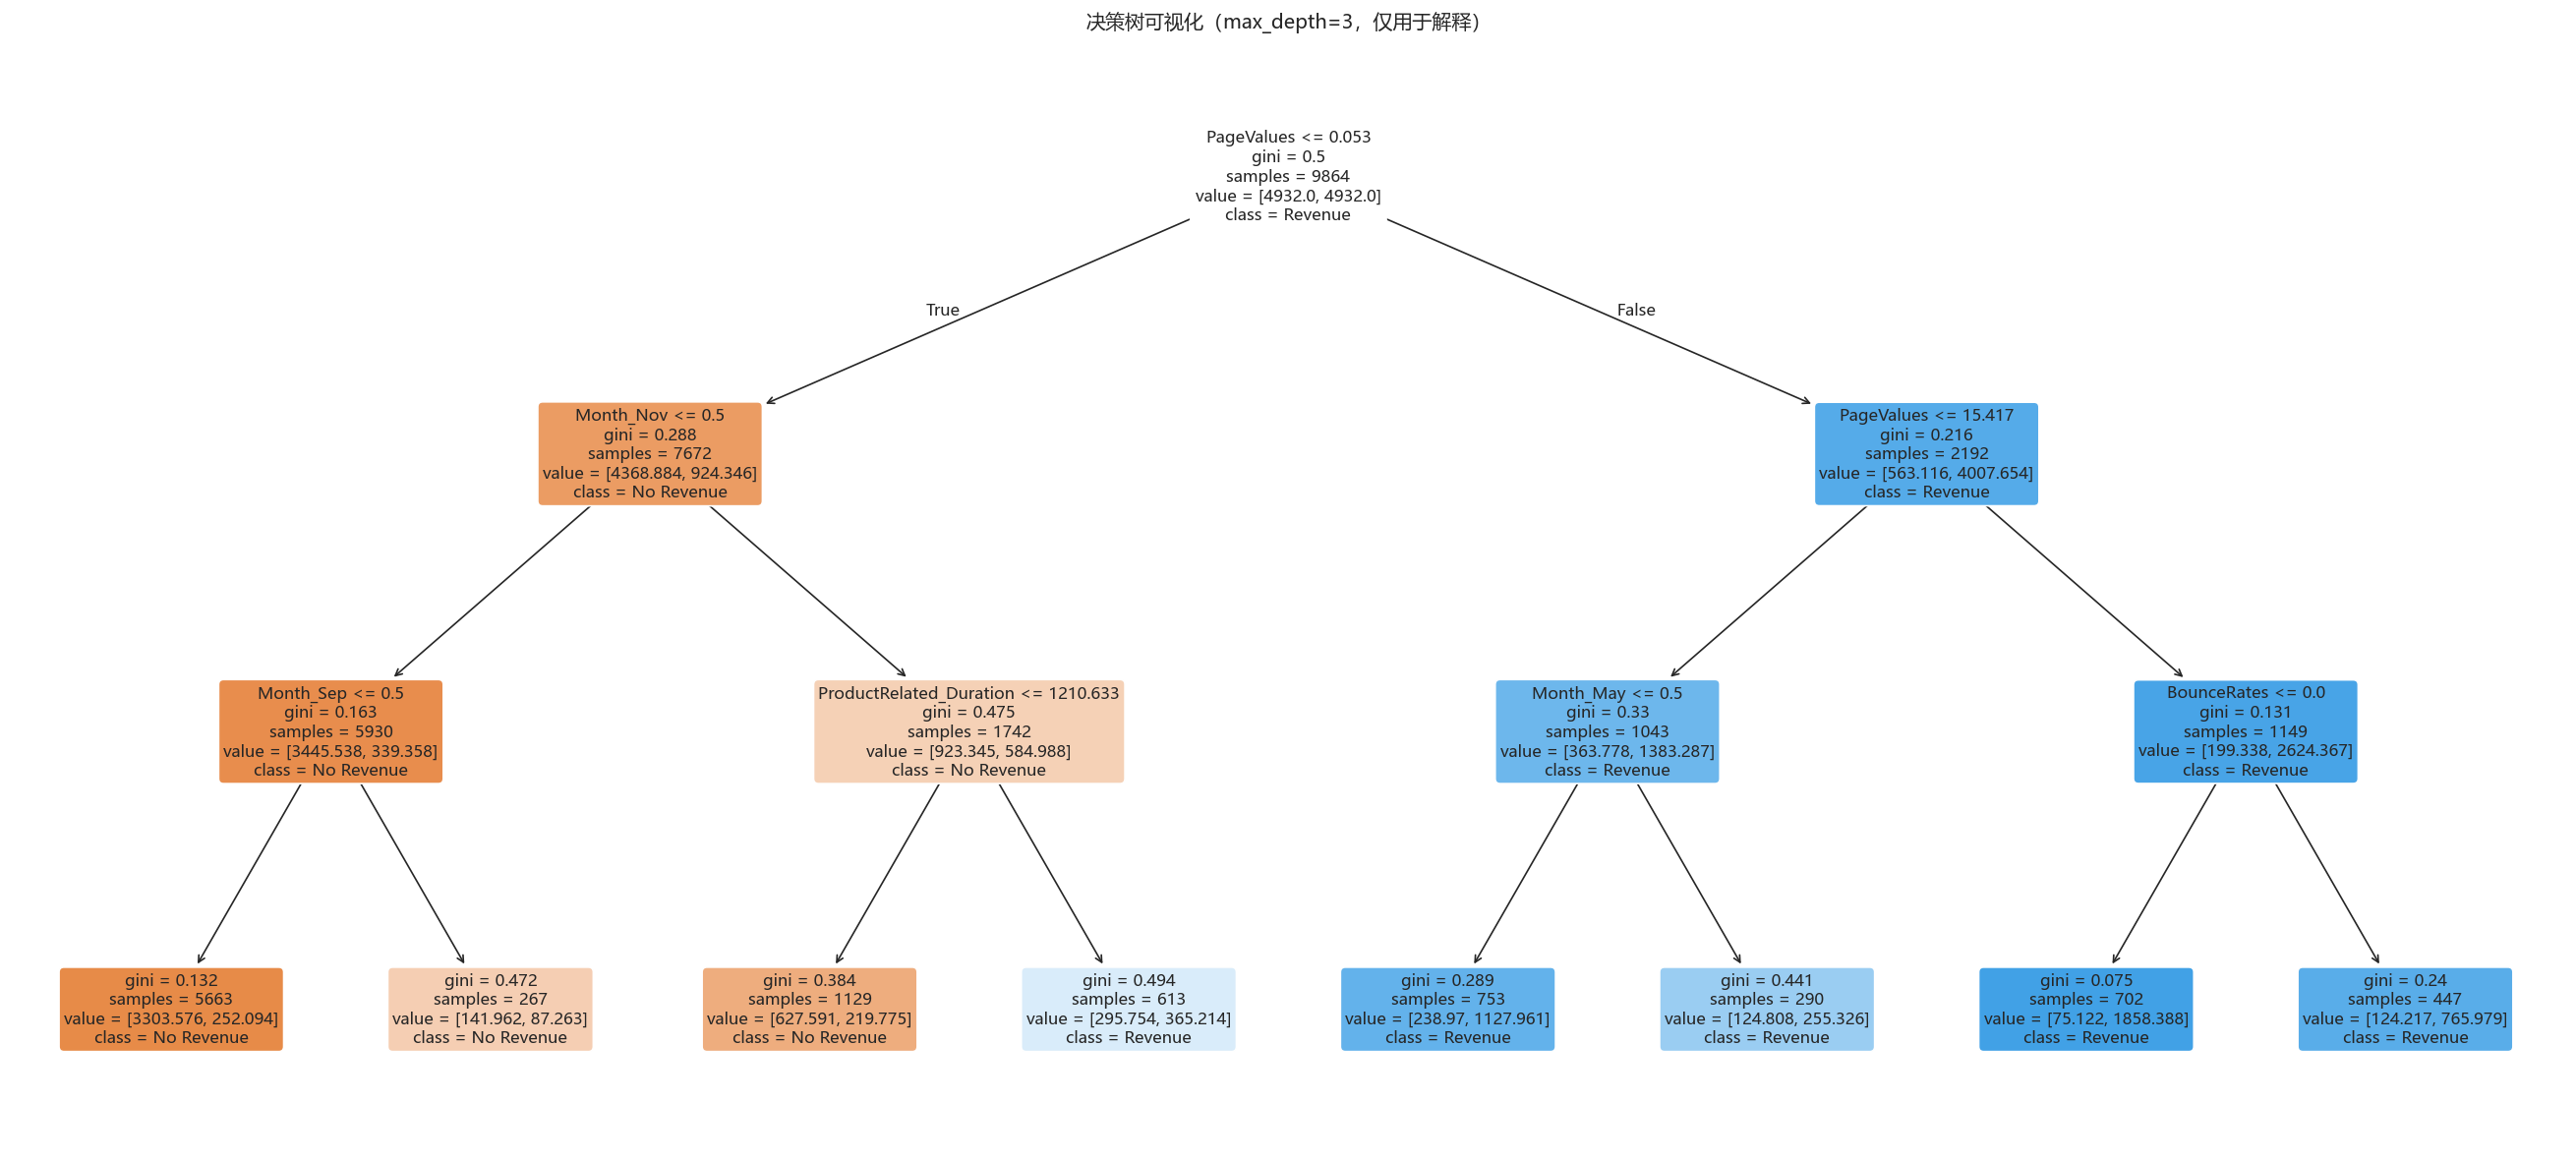

浅层决策树在测试集上的准确率: 0.8325
（此处的浅树仅用于可视化解释，实际评估仍以 Section 4 训练的完整决策树为准）


In [33]:
# 为可读性，限制深度后重新训练一棵浅层决策树用于可视化
# 说明：models["Decision Tree"] 是完整深度的训练模型，直接画出来过于庞大
#       这里用相同的训练数据拟合一棵 max_depth=3 的树，仅用于理解分裂路径
shallow_dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    class_weight=class_weight_option
)
shallow_dt.fit(X_train, y_train)

plt.figure(figsize=(22, 10))
plot_tree(
    shallow_dt,
    feature_names=feat_names,
    class_names=["No Revenue", "Revenue"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("决策树可视化（max_depth=3，仅用于解释）")
plt.tight_layout()
plt.show()

print(f"浅层决策树在测试集上的准确率: {shallow_dt.score(X_test, y_test):.4f}")
print("（此处的浅树仅用于可视化解释，实际评估仍以 Section 4 训练的完整决策树为准）")

## Part 7: 结论与总结

综合 Section 4 的 5 折交叉验证结果与 Section 5 的测试集评估，选出最终推荐模型并给出业务解读。

In [34]:
# 以 F1-Score 作为首要选型依据（类不平衡下更稳健），并列出全部关键指标
recommended_row = final_summary_df.iloc[0]
recommended_name = recommended_row["Model"]
recommended_model = models[recommended_name]

print("=" * 60)
print("           最终推荐模型")
print("=" * 60)
print(f"模型名称     : {recommended_name}")
print(f"模型类型     : {type(recommended_model).__name__}")
print(f"交叉验证 F1  : {recommended_row['CV F1']}")
print(f"测试集 Acc   : {recommended_row['Test Acc']}")
print(f"Precision    : {recommended_row['Precision']}")
print(f"Recall       : {recommended_row['Recall']}")
print(f"F1-Score     : {recommended_row['F1']}")
print(f"AUC          : {recommended_row['AUC']}")

if hasattr(recommended_model, "get_params"):
    params = recommended_model.get_params()
    key_keys = ["n_estimators", "max_depth", "min_samples_split", "C", "gamma", "kernel"]
    shown = {k: params[k] for k in key_keys if k in params}
    if shown:
        print("关键超参数   :", shown)
print("=" * 60)

           最终推荐模型
模型名称     : Random Forest
模型类型     : RandomForestClassifier
交叉验证 F1  : 0.6741
测试集 Acc   : 0.8938
Precision    : 0.6667
Recall       : 0.6283
F1-Score     : 0.6469
AUC          : 0.9211
关键超参数   : {'n_estimators': 400, 'max_depth': 20, 'min_samples_split': 5}


### a. 四模型对比回顾

In [35]:
print("Section 4/5 汇总表（按 F1 降序）：")
display(final_summary_df)

top3_features = importances.head(3).index.tolist()
print("\n影响购买意向最关键的 Top 3 特征（来自随机森林）：")
for i, feat in enumerate(top3_features, 1):
    print(f"  {i}. {feat}  (importance = {importances[feat]:.4f})")

Section 4/5 汇总表（按 F1 降序）：


,Model,CV F1,Test Acc,Precision,Recall,F1,AUC
0,Random Forest,0.6741,0.8938,0.6667,0.6283,0.6469,0.9211
1,SVM (RBF),0.6547,0.8719,0.5679,0.7225,0.6359,0.8986
2,Decision Tree,0.6327,0.8382,0.4871,0.8429,0.6174,0.9133
3,Naive Bayes,0.2920,0.2530,0.1697,0.9817,0.2894,0.5745



影响购买意向最关键的 Top 3 特征（来自随机森林）：
  1. PageValues  (importance = 0.3818)
  2. ExitRates  (importance = 0.0944)
  3. ProductRelated_Duration  (importance = 0.0822)


### b. 结论

**数据层面**
- 原始数据 12330 条，正类（产生购买）占比约 15%，存在明显类别不平衡；本项目全程使用 `class_weight="balanced"` 缓解该问题，避免 SMOTE 合成样本带来的潜在偏差。
- 数值特征经 `StandardScaler` 标准化，类别特征经 `pd.get_dummies` 独热编码，树模型直接使用原特征、NB / SVM 使用标准化后的特征。

**聚类洞察（Section 3）**
- K-Means 在 K=3/4 下得到稳定分群，通过 PageValues、BounceRates、Revenue 均值能够清晰区分"高意向用户"、"跳出型用户"和"浏览型用户"；将聚类标签作为附加特征送入随机森林后，基线准确率能保持或略有提升。

**建模结论（Section 4/5）**
- 四个模型中，以 **F1-Score** 为选型标准（类不平衡场景下比单纯 Accuracy 更能反映正类识别能力）选出的模型即为上方推荐模型，其在 5 折 CV 与测试集上的表现一致。
- 随机森林特征重要性显示：`PageValues`、`ExitRates`、`ProductRelated_Duration` 等行为类指标对购买意向的判断最为关键，这与 EDA 中"PageValues 越高越可能转化"的直觉一致。
- 决策树可视化（前 3 层）进一步解释了最上层分裂几乎都由 `PageValues` 主导，符合业务直觉。
